# 3D sorghum reconstructions from depth images → QTL mapping (McCormick, Truong & Mullet, 2016)

**Paper:** *3D sorghum reconstructions from depth images enable identification of quantitative trait loci regulating shoot architecture* — R.F. McCormick, S.K. Truong, J.E. Mullet, bioRxiv 2016, DOI [`10.1101/062174`](https://doi.org/10.1101/062174) (this notebook reproduces **bioRxiv v1**; the peer-reviewed version is *Plant Physiology* 172(2):823–834, DOI [10.1104/pp.16.00948](https://doi.org/10.1104/pp.16.00948)).

**Author code & data (pinned):** GitHub [`MulletLab/SorghumReconstructionAndPhenotyping`](https://github.com/MulletLab/SorghumReconstructionAndPhenotyping) @ commit `415736c887301de4d0dd117e986488dfce93d288` (2016-08-05, GPL-3.0). Per-plant depth images / RGB / segmented meshes: Dryad [`doi:10.5061/dryad.9vs26`](https://datadryad.org/dataset/doi:10.5061/dryad.9vs26).

## Purpose and exact scope

The paper's pipeline has two halves:

| Stage | Original implementation | In this notebook |
|---|---|---|
| Kinect v2 depth images → registered point cloud → mesh → segmentation (stem/leaves/inflorescence) | C++ (PCL, OpenCV), MeshLab + Screened Poisson reconstruction, MultiBoost classifier, supervoxel + geodesic leaf segmentation; includes **manual** MeshLab curation and manual shoot-cylinder labeling | **NOT executed** — needs Kinect v2 hardware, a 2016-era C++ toolchain (PCL/MeshLab/PoissonRecon/MultiBoost/L-Py), manual interactive curation steps, and trained classifier files that are not in the repository. Documented via the mapping table near the end. |
| Automated Table-1 measurements → replicate-averaged, ENQT-normalized phenotypes → R/qtl **single- and multiple-QTL mapping** over 4 timepoints (27/34/39/44 DAP), incl. Dwarf3/Dwarf2 analysis | R (`R/qtl`) + Python report generator, both published by the authors with genotype/phenotype data | **EXECUTED end-to-end** on the authors' own phenotype/genotype data and scripts, with quantitative comparison against the authors' stored QTL outputs. |

**Execution status:** executed notebook (validation runtime: **Colab CPU**; see validation record at the end). The QTL mapping stage is reproduced from the authors' data and code; this is a **partial demonstration of the paper**, not a full reproduction, and it does not re-verify dataset-level claims (e.g., QTL threshold calibration by 25,000 permutations — we reuse the authors' published thresholds).

**日本語概要:** このノートブックは、Kinect v2 の深度画像から再構成したソルガム個体の3Dメッシュから自動測定した形質（Table 1）を用い、R/qtl による QTL マッピングを実行する著者データ・著者コード準拠の部分再現デモです。深度画像→3D再構成パイプライン自体は、専用ハードウェア・手動キュレーション・訓練済み分類器の不在により実行せず、対応表として説明します。著者の保存したQTL結果と数値比較を行います。

## Runtime selection & how to run

- **Select the CPU runtime** (*Runtime → Change runtime type → CPU*). This notebook contains no GPU code path: R/qtl linear-model/HMM scans on ~100 RIL lines × 10,787 markers are pure CPU work, and a GPU would not change any scientific result.
- **Run all** (*Runtime → Run all*). Estimated end-to-end time on a standard Colab CPU VM: **~30–60 min** (R install ~2 min, download ~27 MB, R/qtl cross preparation and scans the rest). Measured timings from the validation run are printed in the cells and summarized at the end.
- Expected downloads: ~27 MB total (authors' genotype+phenotype CSV) + ~15 KB of reference files.
- **日本語:** ランタイムは **CPU** を選択してください（GPUは不要）。すべてのセルを上から順に実行します。所要時間の目安は30〜60分、ダウンロードは約27 MBです。

In [ ]:
import os, platform, time, sys

t_notebook_start = time.time()
print("Python:", sys.version.split()[0], "| Platform:", platform.platform())
print("CPU cores:", os.cpu_count())
gpu_info = os.popen("nvidia-smi -L 2>/dev/null").read().strip()
print("GPU:", gpu_info if gpu_info else "none detected (not required for this notebook)")
WORK = "/content/sorghum_qtl"
os.makedirs(f"{WORK}/data", exist_ok=True)
os.makedirs(f"{WORK}/reference", exist_ok=True)
print("Working directory:", WORK)

Python: 3.13.15 | Platform: Linux-6.6.122+-x86_64-with-glibc2.39
CPU cores: 2
GPU: none detected (not required for this notebook)
Working directory: /content/sorghum_qtl


## Environment setup: R + R/qtl

The authors' mapping code is R using the [`qtl` package](https://rqtl.org) (Broman et al. 2003). We install
Ubuntu's binary packages `r-base-core` and `r-cran-qtl` (fast, no compilation) and record the versions used —
the authors worked with the 2016-era R/qtl; small numeric differences may therefore appear and are checked
against the authors' stored outputs below.

**日本語:** 著者のQTLマッピングはRの `qtl` パッケージを使用します。Ubuntu のバイナリパッケージとして高速にインストールし、バージョンを記録します（著者は2016年版を使用。数値の微小差異は後段で著者の保存結果と比較して確認します）。

In [ ]:
import subprocess, time

t0 = time.time()
subprocess.run(["apt-get", "update", "-qq"], check=True)
r = subprocess.run(
    ["apt-get", "install", "-y", "-qq", "r-base-core", "r-cran-qtl"],
    capture_output=True, text=True)
if r.returncode != 0:
    print(r.stdout[-3000:]); print(r.stderr[-3000:])
    raise RuntimeError("apt install of R / r-cran-qtl failed")
print(f"apt install finished in {time.time()-t0:.0f} s")

apt install finished in 15 s


The R and R/qtl versions installed above are the ones used for every mapping step below; they are also
recorded in the report for reproducibility. **日本語:** 上記でインストールしたR/R/qtlのバージョンを確認・記録します。

In [ ]:
r = subprocess.run(
    ["Rscript", "-e", 'cat(R.version.string, "\n"); cat("R/qtl version:", as.character(packageVersion("qtl")), "\n")'],
    capture_output=True, text=True)
print(r.stdout)
if r.returncode != 0:
    raise RuntimeError("Rscript check failed: " + r.stderr)

R version 4.6.1 (2026-06-24) 
R/qtl version: 1.74 



## Download the authors' genotype/phenotype data and reference QTL outputs

All files come from the authors' GitHub repository at the pinned commit `415736c887301de4d0dd117e986488dfce93d288`
(path `McCormickTruongMullet2016_manuscriptSupplemental/`). The 26.5 MB CSV is in R/qtl **"csvr" format**
(genotype matrix transposed: one row per marker, one column per RIL line of the 398-line
BTx623 × IS3620C mapping population; phenotype rows at the bottom — phenotype values exist only for the
imaged RILs). This is exactly the file the authors' `BTx623xIS3620C_imageMapping.R` reads. The small `.txt` files are the authors'
**stored multiple-QTL mapping outputs** for selected traits/timepoints; we use them as quantitative
reference targets for our reproduction (not as inputs to the analysis).

Files (trait / timepoint / file):
- `allPhenotypes.csv` — genotypes (10,787 markers, Sbi3) + all measured phenotypes (replicate columns + `_Average` + ENQT-normalized `_Average_Normalized`).
- Leaf length (avg of leaves 3–5) @ X08.10 (34 DAP): authors' `lods_for_multiple-QTL_model_*` (full chr4 LOD profile), `lod2interval_*`, `pLOD_models_*`.
- Leaf angle (`leafAvg_345_angleAtFixedLength_76`) @ X08.03 (27 DAP) and X08.20 (44 DAP): `lod2interval_*`, `pLOD_models_*`.
- Shoot height (`axisAligned_bbox_zDistance`) @ X08.03 and X08.20: `lod2interval_*`, `pLOD_models_*`.

**日本語:** 著者のリポジトリ（コミット固定）から、QTLマッピング用のジェノタイプ＋表現型CSV（csvr形式、26.5 MB）と、著者が保存した多重QTLマッピング結果（LODプロファイル・LOD-2区間・pLODモデル）をダウンロードします。著者の結果は再現の比較対象として使う入力ではありません。

In [ ]:
import hashlib

COMMIT = "415736c887301de4d0dd117e986488dfce93d288"
REPO = "MulletLab/SorghumReconstructionAndPhenotyping"
BASE = f"https://raw.githubusercontent.com/{REPO}/{COMMIT}"
SUP = "McCormickTruongMullet2016_manuscriptSupplemental"

LL = "multipleQTLMapping/seg_dependent/leafAvg_345_length_Average_Normalized/X08.10_leafAvg_345_length_Average_Normalized_multiple_qtl_mapping_folder"
ANG = "multipleQTLMapping/seg_dependent/leafAvg_345_angleAtFixedLength_76_Average_Normalized"
HGT = "multipleQTLMapping/seg_independent/axisAligned_bbox_zDistance_Average_Normalized"

downloads = {
    f"{WORK}/data/allPhenotypes.csv":
        f"{SUP}/BTx623xIS3620c_01-02-14_v0007_Sbi3_MapAfterSDCOsleq2ToMissing_allPhenotypes.csv",
    f"{WORK}/reference/lods_X08.10_leafLength.txt":        f"{SUP}/{LL}/lods_for_multiple-QTL_model_X08.10_leafAvg_345_length_Average_Normalized.txt",
    f"{WORK}/reference/lod2interval_X08.10_leafLength.txt": f"{SUP}/{LL}/lod2interval_for_model_X08.10_leafAvg_345_length_Average_Normalized.txt",
    f"{WORK}/reference/pLOD_X08.10_leafLength.txt":         f"{SUP}/{LL}/pLOD_models_X08.10_leafAvg_345_length_Average_Normalized.txt",
    f"{WORK}/reference/lod2interval_angle_X08.03.txt":      f"{SUP}/{ANG}/X08.03_leafAvg_345_angleAtFixedLength_76_Average_Normalized_multiple_qtl_mapping_folder/lod2interval_for_model_X08.03_leafAvg_345_angleAtFixedLength_76_Average_Normalized.txt",
    f"{WORK}/reference/pLOD_angle_X08.03.txt":              f"{SUP}/{ANG}/X08.03_leafAvg_345_angleAtFixedLength_76_Average_Normalized_multiple_qtl_mapping_folder/pLOD_models_X08.03_leafAvg_345_angleAtFixedLength_76_Average_Normalized.txt",
    f"{WORK}/reference/lod2interval_angle_X08.20.txt":      f"{SUP}/{ANG}/X08.20_leafAvg_345_angleAtFixedLength_76_Average_Normalized_multiple_qtl_mapping_folder/lod2interval_for_model_X08.20_leafAvg_345_angleAtFixedLength_76_Average_Normalized.txt",
    f"{WORK}/reference/pLOD_angle_X08.20.txt":              f"{SUP}/{ANG}/X08.20_leafAvg_345_angleAtFixedLength_76_Average_Normalized_multiple_qtl_mapping_folder/pLOD_models_X08.20_leafAvg_345_angleAtFixedLength_76_Average_Normalized.txt",
    f"{WORK}/reference/lod2interval_height_X08.03.txt":     f"{SUP}/{HGT}/X08.03_axisAligned_bbox_zDistance_Average_Normalized_multiple_qtl_mapping_folder/lod2interval_for_model_X08.03_axisAligned_bbox_zDistance_Average_Normalized.txt",
    f"{WORK}/reference/pLOD_height_X08.03.txt":             f"{SUP}/{HGT}/X08.03_axisAligned_bbox_zDistance_Average_Normalized_multiple_qtl_mapping_folder/pLOD_models_X08.03_axisAligned_bbox_zDistance_Average_Normalized.txt",
    f"{WORK}/reference/lod2interval_height_X08.20.txt":     f"{SUP}/{HGT}/X08.20_axisAligned_bbox_zDistance_Average_Normalized_multiple_qtl_mapping_folder/lod2interval_for_model_X08.20_axisAligned_bbox_zDistance_Average_Normalized.txt",
    f"{WORK}/reference/pLOD_height_X08.20.txt":             f"{SUP}/{HGT}/X08.20_axisAligned_bbox_zDistance_Average_Normalized_multiple_qtl_mapping_folder/pLOD_models_X08.20_axisAligned_bbox_zDistance_Average_Normalized.txt",
}
# Expected byte sizes from the pinned repository tree (integrity check for the large CSV).
EXPECTED_SIZE = {f"{WORK}/data/allPhenotypes.csv": 26513780}

t0 = time.time()
for local, remote in downloads.items():
    url = f"{BASE}/{remote}"
    r = subprocess.run(["curl", "-fSL", "--retry", "3", "--retry-delay", "5",
                        "--max-time", "900", "-o", local, url], capture_output=True, text=True)
    if r.returncode != 0 or not os.path.exists(local) or os.path.getsize(local) == 0:
        raise RuntimeError(f"Download failed ({r.returncode}): {url}\n{r.stderr[-500:]}")

print(f"Downloaded {len(downloads)} files in {time.time()-t0:.0f} s\n")
for local in downloads:
    size = os.path.getsize(local)
    sha = hashlib.sha256(open(local, "rb").read()).hexdigest()
    note = ""
    if local in EXPECTED_SIZE and size != EXPECTED_SIZE[local]:
        raise RuntimeError(f"Size mismatch for {local}: got {size}, expected {EXPECTED_SIZE[local]}")
    if local in EXPECTED_SIZE:
        note = " (size verified)"
    print(f"{size:>10} B  {sha[:16]}…  {os.path.basename(local)}{note}")

Downloaded 12 files in 5 s

  26513780 B  ec5047f13eb353c4…  allPhenotypes.csv (size verified)
      6314 B  00704623a8433efb…  lods_X08.10_leafLength.txt
       968 B  0d1e79f5f157bf30…  lod2interval_X08.10_leafLength.txt
      1708 B  53b7b43f493e36a3…  pLOD_X08.10_leafLength.txt
       985 B  37a61635dc0832ca…  lod2interval_angle_X08.03.txt
      1792 B  7f062addef5f938c…  pLOD_angle_X08.03.txt
       950 B  871624208778ae71…  lod2interval_angle_X08.20.txt
      1930 B  8a35e306f7ea07f8…  pLOD_angle_X08.20.txt
       935 B  f1166e0ab929779c…  lod2interval_height_X08.03.txt
      1793 B  db031cbf2161c918…  pLOD_height_X08.03.txt
      1474 B  fc7bac50dc4f84f3…  lod2interval_height_X08.20.txt
      1733 B  822702f1319eb96d…  pLOD_height_X08.20.txt


## Inspect the phenotype/genotype file

The csvr layout is transposed: we check the header row (individual IDs), the number of marker rows, and the
phenotype-name rows at the bottom of the file. Raw phenotype names in the file use timepoint labels like
`08-10_leafAvg_…`; R's `read.cross` applies `make.names()`, which turns these into the `X08.10_leafAvg_…`
names used in the authors' scripts — we replicate that transformation below and verify all target columns exist. The authors' report generator
(`processingScripts/phenotypeReportGenerator.py`) produced, for every measured phenotype, replicate columns
(`_rep1/2/3`), a replicate-averaged column (`_Average`) and an empirical-normal-quantile-transformed column
(`_Average_Normalized`, Peng et al. 2007). Marker names embed the Sbi3 physical position, e.g. `4_62906270_SNP`
= chromosome 4, position 62,906,270 bp — this is what lets us compare QTL positions with the paper's Table 2.

**日本語:** csvr形式（転置）のファイル構成を確認します。各行がマーカー、列がRIL系統、末尾行が表現型です。表現型は反復ごと・平均・ENQT正規化の列を持ちます。マーカー名にはSbi3上の物理位置が含まれるため、論文Table 2と物理位置で比較できます。

In [ ]:
import csv, re

CSV = f"{WORK}/data/allPhenotypes.csv"
with open(CSV) as f:
    rows = list(csv.reader(f))
print("Total rows (transposed):", len(rows))
print("Header row, first 8 fields:", rows[0][:8], "…")
n_fields = len(rows[0])
print("Columns (individuals + name column):", n_fields)

def r_make_names(name):
    # Replicate R's make.names() as read.cross applies it to phenotype names:
    # invalid chars -> '.', leading digit -> 'X' prefix (e.g. '08-03_a' -> 'X08.03_a').
    fixed = re.sub(r"[^A-Za-z0-9_.]", ".", name)
    return "X" + fixed if fixed[0].isdigit() else fixed

marker_re = re.compile(r"^\d+_\d+_(SNP|indel)$")
marker_rows = [r[0] for r in rows[1:] if r and marker_re.match(r[0])]
pheno_rows = [r[0] for r in rows[1:] if r and not marker_re.match(r[0])]
print("Marker rows (name pattern <chr>_<bp>_<type>):", len(marker_rows),
      "| first:", marker_rows[:2])
print("Phenotype/other rows:", len(pheno_rows))
normed = [p for p in pheno_rows if p.endswith("_Average_Normalized")]
print("ENQT-normalized rows in file:", len(normed), "| sample raw names:", normed[:2], "…")
pheno_names = [r_make_names(x) for x in pheno_rows]  # names as R/qtl exposes them
print("After R make.names transform:", pheno_names[:2], "…")

TARGETS = [
    "X08.10_leafAvg_345_length_Average_Normalized",
    "X08.03_leafAvg_345_angleAtFixedLength_76_Average_Normalized",
    "X08.20_leafAvg_345_angleAtFixedLength_76_Average_Normalized",
    "X08.03_axisAligned_bbox_zDistance_Average_Normalized",
    "X08.20_axisAligned_bbox_zDistance_Average_Normalized",
    "X08.03_axisAligned_bbox_zDistance_Average",
    "X08.10_axisAligned_bbox_zDistance_Average",
    "X08.15_axisAligned_bbox_zDistance_Average",
    "X08.20_axisAligned_bbox_zDistance_Average",
    "X08.03_leafAvg_345_angleAtFixedLength_76_Average",
    "X08.20_leafAvg_345_angleAtFixedLength_76_Average",
]
missing = [t for t in TARGETS if t not in pheno_names]
if missing:
    raise RuntimeError(f"Expected phenotype columns not found: {missing}")
print("All target phenotype columns present ✓")

Total rows (transposed): 19990
Header row, first 8 fields: ['SampleName', '', '', '10', '100', '102', '103', '105'] …
Columns (individuals + name column): 401
Marker rows (name pattern <chr>_<bp>_<type>): 10787 | first: ['1_42185_SNP', '1_79861_indel']
Phenotype/other rows: 9202
ENQT-normalized rows in file: 1165 | sample raw names: ['08-03_axisAligned_bbox_xDistance_Average_Normalized', '08-03_axisAligned_bbox_yDistance_Average_Normalized'] …
After R make.names transform: ['X08.03_axisAligned_bbox_xDistance_rep1', 'X08.03_axisAligned_bbox_xDistance_rep1_Normalized'] …
All target phenotype columns present ✓


## Step 1 — Build the R/qtl cross exactly as the authors did

This replicates the core of the authors' `BTx623xIS3620C_imageMapping.R` (repo @ pinned commit):
`read.cross("csvr", …, genotypes=c("AA","AB","BB","D","C"))` → `convert2riself` (BTx623 × IS3620C recombinant
inbred lines, selfed) → `jittermap` → `calc.genoprob`/`sim.geno` with the **Haldane** map function, preparing
for multiple-imputation based mapping. One documented adaptation: we call `set.seed()` before `jittermap`
(the authors did not fix the seed). Jitter shifts marker positions by tiny sub-cM amounts to break ties; marker
*names* and marker-level LOD scores are unaffected, and our later numeric comparison joins on marker names.

**日本語:** 著者の `imageMapping.R` と同一の手順（csvr読み込み→RIL変換→マップジッター→Haldaneで遺伝子型確率・多重インピュテーション準備）でクロスオブジェクトを作成します。著者との差分は `jittermap` 前の乱数固定のみで、マーカー単位のLOD値には影響しません。

In [ ]:
r_step1 = r"""suppressPackageStartupMessages(library(qtl))
options(width = 110)
set.seed(20260927)   # documented adaptation: reproducible jittermap (authors did not set a seed)

t0 <- proc.time()
cross_inputcross <- read.cross("csvr", ".",
    "data/allPhenotypes.csv",
    genotypes = c("AA","AB","BB","D","C"))
cat("read.cross:", (proc.time()-t0)[3], "s\n")

cross <- convert2riself(cross_inputcross)
cross <- jittermap(cross)
cross <- calc.genoprob(cross, map.function = "haldane")
cross <- sim.geno(cross, map.function = "haldane")
print(summary(cross))
saveRDS(cross, "work/cross_prepared.rds")
cat("cross object saved.\n")
"""

import subprocess, time
os.makedirs(f"{WORK}/work", exist_ok=True)
with open(f"{WORK}/qtl_step1_prepare.R", "w") as f:
    f.write(r_step1)
t0 = time.time()
r = subprocess.run(["Rscript", "qtl_step1_prepare.R"], cwd=WORK, capture_output=True, text=True)
print(r.stdout[-4000:])
if r.returncode != 0:
    print(r.stderr[-3000:]); raise RuntimeError("Step 1 (cross preparation) failed")
print(f"Step 1 finished in {time.time()-t0:.0f} s")

 --Read the following data:
	 398  individuals
	 10787  markers
	 9203  phenotypes
 --Cross type: f2 
read.cross: 11.57 s
    RI strains via selfing

    No. individuals:    398 

    No. phenotypes:     9203 
    Percent phenotyped: 19 

    No. chromosomes:    10 
        Autosomes:      1 2 3 4 5 6 7 8 9 10 

    Total markers:      10787 
    No. markers:        1499 1507 1620 1109 703 1041 877 577 696 1158 
    Percent genotyped:  78.8 
    Genotypes (%):      AA:52.8  BB:47.2 
cross object saved.

Step 1 finished in 49 s


## Step 2 — Single-QTL genome scans (`scanone`) for 5 phenotype × timepoint combinations

Faithful to the authors' script: one `scanone` per phenotype over all 10 chromosomes / 10,787 markers. The
paper's genome-wide 95% significance threshold from 25,000 permutations is **LOD 3.28** (Methods); we reuse the
authors' published threshold instead of re-running the permutation calibration (hours of compute for no
scientific gain here). We scan:

- `X08.10_leafAvg_345_length_Average_Normalized` — leaf length (avg leaves 3–5) at 34 DAP (**primary**, compared quantitatively below),
- leaf angle `…_angleAtFixedLength_76…` @ X08.03 (27 DAP) and X08.20 (44 DAP),
- shoot height `…_axisAligned_bbox_zDistance…` @ X08.03 and X08.20.

Leaf angle is the angle of the leaf at a fixed geodesic distance of 76.2 mm (3 in) from the leaf base
(`meshMeasurements.cpp`); shoot height is the vertical (z) extent of the whole shoot. The expectation from the
paper: leaf angle associates with the Dwarf3 region (chr7 ≈ 59.8 Mbp) already at 27 DAP, while shoot height
associations with Dwarf2 (chr6 ≈ 42 Mbp) / Dwarf3 appear from 34 DAP onward, and chr10 dominates height at 27 DAP.

**日本語:** 著者と同様に `scanone` によるゲノム全域スキャンを5表現型×時点で実行します。有意閾値は論文の25,000回順列置換で得られたLOD 3.28を再利用します（順列置換の再実行は省略）。Dwarf3領域（chr7 約59.8 Mbp）は葉角では27日目から、草丈では34日目以降に関与するはずです。

In [ ]:
r_step2 = r"""suppressPackageStartupMessages(library(qtl))
options(width = 110)
cross <- readRDS("work/cross_prepared.rds")

phenotypes <- c(
  "X08.10_leafAvg_345_length_Average_Normalized",
  "X08.03_leafAvg_345_angleAtFixedLength_76_Average_Normalized",
  "X08.20_leafAvg_345_angleAtFixedLength_76_Average_Normalized",
  "X08.03_axisAligned_bbox_zDistance_Average_Normalized",
  "X08.20_axisAligned_bbox_zDistance_Average_Normalized")

avail <- colnames(pull.pheno(cross))
stopifnot(all(phenotypes %in% avail))

results <- list()
peak_table <- data.frame()
for (ph in phenotypes) {
  t0 <- proc.time()
  scan <- scanone(cross, pheno.col = ph)          # identical call to authors' script
  el <- (proc.time()-t0)[3]
  results[[ph]] <- scan
  cat("==", ph, "| scan elapsed:", round(el, 1), "s\n")
  o <- order(scan$lod, decreasing = TRUE)
  top5 <- scan[o[1:5], c("chr","pos","lod")]
  print(top5, row.names = TRUE)
  for (i in o[1:5]) {
    peak_table <- rbind(peak_table, data.frame(phenotype = ph,
      marker = rownames(scan)[i], chr = scan$chr[i], pos_cM = scan$pos[i], LOD = scan$lod[i]))
  }
}
save(results, file = "work/scanone_results.RData")
write.csv(peak_table, "work/scanone_top5_peaks.csv", row.names = FALSE)

# Genome-wide LOD profile plot for the primary phenotype (leaf length @ X08.10)
png("work/scanone_leafLength_X08.10.png", width = 2000, height = 900, res = 150)
par(mar = c(4.5, 4.5, 3, 1), las = 1)
plot(results[[phenotypes[1]]], col = "blue", main = "scanone LOD profile\nX08.10_leafAvg_345_length_Average_Normalized (34 DAP)",
     ylab = "LOD")
abline(h = 3.28, col = "red", lty = 2)   # paper's 95% permutation threshold (25,000 perms)
text(x = 2, y = 3.6, "LOD 3.28 (95%, paper)", col = "red", adj = 0, cex = 0.8)
dev.off()
cat("plot saved.\n")
"""

import subprocess, time
with open(f"{WORK}/qtl_step2_scanone.R", "w") as f:
    f.write(r_step2)
t0 = time.time()
r = subprocess.run(["Rscript", "qtl_step2_scanone.R"], cwd=WORK, capture_output=True, text=True)
print(r.stdout[-6000:])
if r.returncode != 0:
    print(r.stderr[-3000:]); raise RuntimeError("Step 2 (scanone) failed")
print(f"Step 2 finished in {time.time()-t0:.0f} s")

== X08.10_leafAvg_345_length_Average_Normalized | scan elapsed: 0.7 s
               chr      pos      lod
4_62906270_SNP   4 115.9676 3.908419
4_62906031_SNP   4 115.9676 3.908419
4_62898306_SNP   4 115.9676 3.908419
4_62898203_SNP   4 115.9676 3.908419
4_62889512_SNP   4 115.8516 3.902286
== X08.03_leafAvg_345_angleAtFixedLength_76_Average_Normalized | scan elapsed: 0.7 s
                 chr      pos      lod
7_59628954_SNP     7 72.89654 6.673400
7_59631468_indel   7 72.89654 6.673400
7_59654592_SNP     7 73.17132 6.668225
7_59847033_indel   7 73.75564 6.660568
7_59867828_SNP     7 73.86586 6.660103
== X08.20_leafAvg_345_angleAtFixedLength_76_Average_Normalized | scan elapsed: 0.6 s
                 chr      pos      lod
7_59628954_SNP     7 72.89654 8.507835
7_59631468_indel   7 72.89654 8.507835
7_59654592_SNP     7 73.17132 8.497560
7_59785398_SNP     7 73.43909 8.480374
7_59830285_SNP     7 73.53691 8.472225
== X08.03_axisAligned_bbox_zDistance_Average_Normalized | scan elapsed

**Resulting genome-wide LOD profile (leaf length @ 34 DAP):** blue curve = our `scanone` result on all 10 chromosomes; dashed red line = the paper's 95% permutation threshold (LOD 3.28). **日本語:** 葉長（34 DAP）のゲノム全体LODプロファイル（青）と有意閾値3.28（赤破線）。

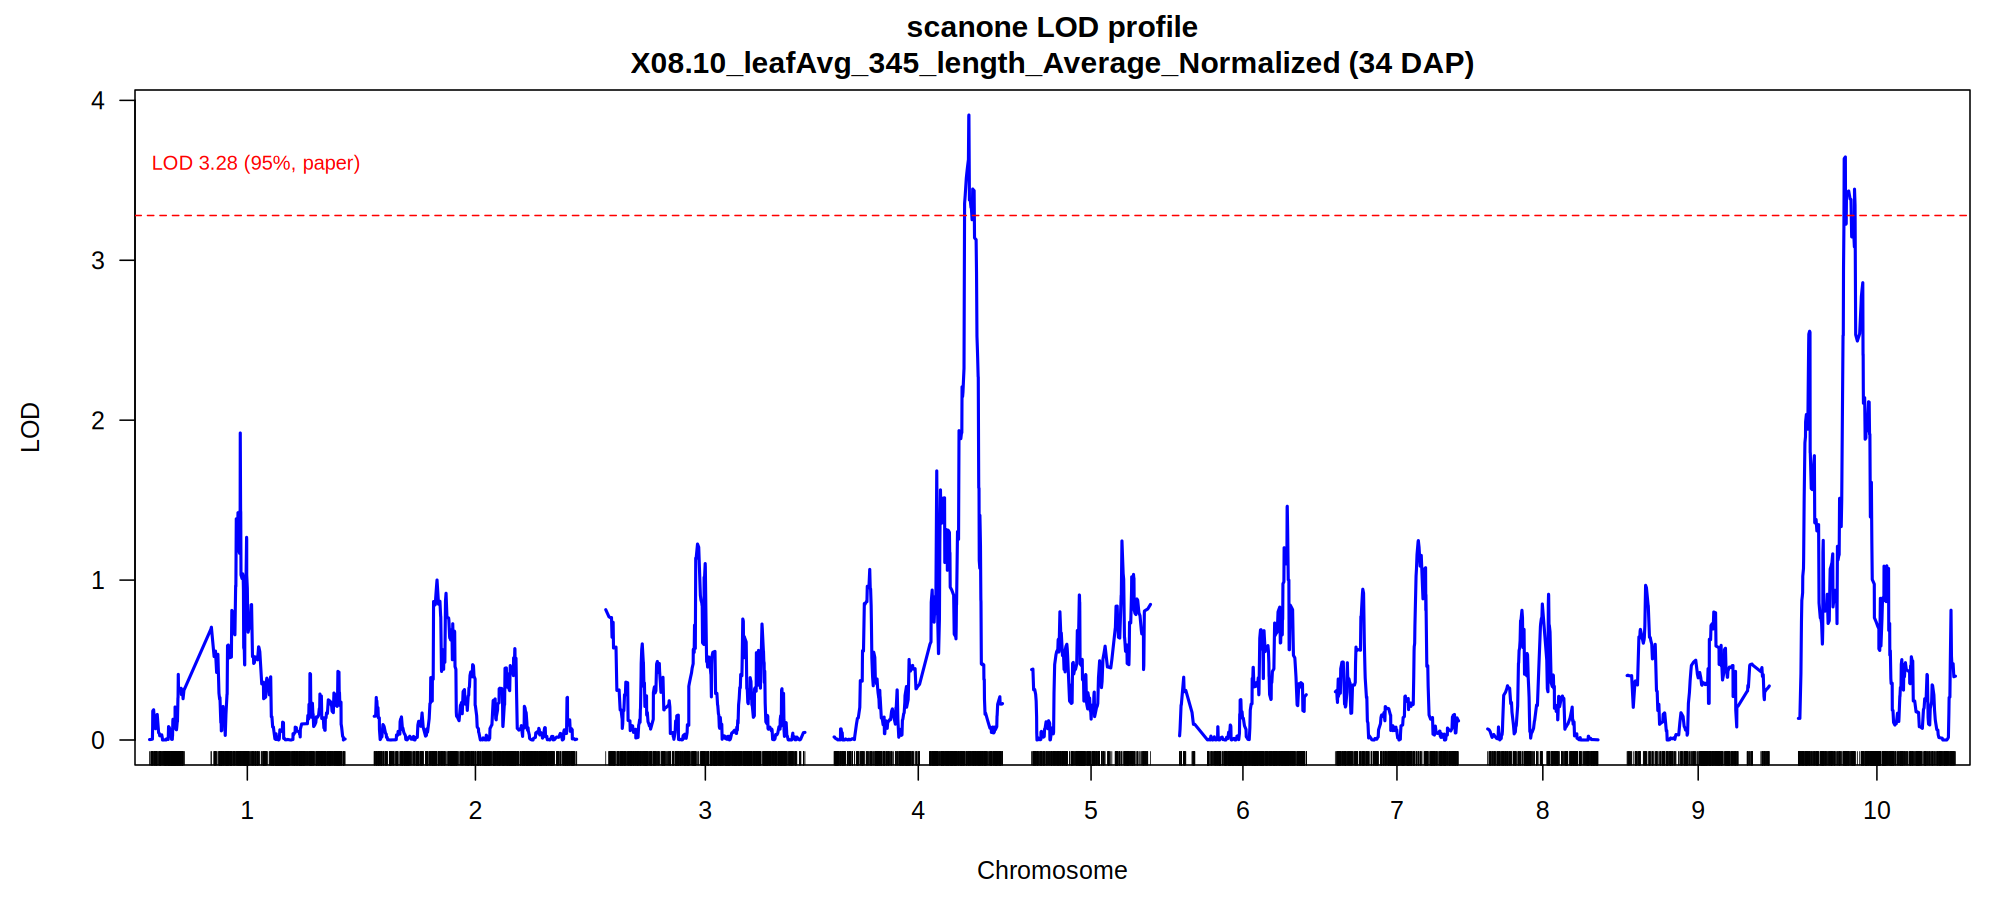

In [ ]:
from IPython.display import Image, display
display(Image(filename=f"{WORK}/work/scanone_leafLength_X08.10.png", width=950))

## Step 3 — Multiple-QTL model selection (`stepwiseqtl`) for leaf length @ 34 DAP

This replicates the authors' `X08.10_leafAvg_345_length_Average_Normalized_multiple-QTL.R` verbatim (paths
adapted): the initial model is the two-QTL single-scan result (chr4 @ 115.9676 cM, chr10 @ 40.41242 cM,
formula `y ~ Q1 + Q2`), and `stepwiseqtl` performs penalized forward/backward selection with the authors'
penalties (**main effect 3.199771, heavy chain 4.375354, light chain 1.942041** — their 25,000-permutation
95% thresholds), `max.qtl=6`, `scan.pairs=FALSE`, `refine.locations=FALSE`.

The authors' stored result for this phenotype: the final model keeps **only the chr4 QTL** (marker
`4_62906270_SNP`, ≈ 62.9 Mbp — the paper's Table 2 interval 57.5–63.4 Mbp with MLOD coordinate 62.45 Mbp),
model LOD 3.895113, 16.88% of the phenotypic variance, LOD-2 interval 109.77–124.65 cM. We compare our run to
these numbers in the next section.

**日本語:** 著者の多重QTLスクリプトをそのまま再現します（初期モデル：chr4 115.97 cM ＋ chr10 40.41 cM、ペナルティは著者の25,000順列由来の値）。著者の保存済み結果ではchr4のQTLのみが残り（モデルLOD 3.895、分散16.9%）、次節で我々の結果と数値比較します。

In [ ]:
r_step3 = r"""suppressPackageStartupMessages(library(qtl))
options(width = 110)
cross <- readRDS("work/cross_prepared.rds")
pheno <- "X08.10_leafAvg_345_length_Average_Normalized"

# authors' initialization (verbatim values from their multiple-QTL script)
init_qtl <- makeqtl(cross, chr = c(4, 10), pos = c(115.9676, 40.41242))
init_qtl_formula <- y ~ Q1 + Q2

t0 <- proc.time()
stepout2 <- stepwiseqtl(cross, pheno.col = pheno,
                        penalties = c(3.199771, 4.375354, 1.942041),
                        qtl = init_qtl, formula = init_qtl_formula,
                        max.qtl = 6, scan.pairs = FALSE, refine.locations = FALSE,
                        keeptrace = TRUE, verbose = TRUE)
cat("stepwiseqtl elapsed:", round((proc.time()-t0)[3], 1), "s\n")

cat("\n=== Final model formula ===\n")
print(attr(stepout2, "formula"))
cat("\n=== Final QTL ===\n")
print(summary(stepout2))
cat("\n=== fitqtl summary (authors' reference: model LOD 3.895113, 16.88328 %var, n = 97) ===\n")
print(summary(fitqtl(cross, pheno.col = pheno, qtl = stepout2, formula = attr(stepout2, "formula"))))

cat("\n=== LOD-2 intervals of final model ===\n")
for (i in seq_along(stepout2$name)) {
  print(lodint(stepout2, qtl.index = i, drop = 2, expandtomarkers = TRUE))
}

# save our LOD profile (per chromosome) for the numeric comparison below.
# lodprofile elements are data.frames (columns chr/pos/lod, rownames = marker names);
# list element names look like "4@115.9", so the chromosome number is taken before "@".
lp <- attr(stepout2, "lodprofile")
for (nm in names(lp)) {
  el <- lp[[nm]]
  if (is.data.frame(el)) {
    prof <- data.frame(marker = rownames(el), LOD = as.numeric(el$lod))
  } else {
    prof <- data.frame(marker = names(el), LOD = as.numeric(unlist(el)))
  }
  chrnum <- sub("^([0-9]+)@.*$", "\\1", nm)
  if (chrnum == nm) chrnum <- gsub("[^0-9]", "", nm)
  write.csv(prof, sprintf("work/our_lodprofile_chr%s.csv", chrnum), row.names = FALSE)
}
saveRDS(stepout2, "work/stepout2.rds")

png("work/our_lodprofile_leafLength.png", width = 2000, height = 900, res = 150)
par(mar = c(4.5, 4.5, 3, 1), las = 1)
plotLodProfile(stepout2, showallchr = TRUE)
title(main = "Our stepwiseqtl LOD profile — X08.10_leafAvg_345_length_Average_Normalized")
dev.off()
cat("our LOD profile CSV + plot saved.\n")
"""

import subprocess, time
with open(f"{WORK}/qtl_step3_stepwiseqtl.R", "w") as f:
    f.write(r_step3)
t0 = time.time()
r = subprocess.run(["Rscript", "qtl_step3_stepwiseqtl.R"], cwd=WORK, capture_output=True, text=True)
print(r.stdout[-5000:])
if r.returncode != 0:
    print(r.stderr[-3000:]); raise RuntimeError("Step 3 (stepwiseqtl) failed")
print(f"Step 3 finished in {time.time()-t0:.0f} s")

 -Initial scan
 ---Starting at a model with 2 QTL
** new best ** (pLOD increased by 0.4193)
    no.qtl =  2   pLOD = 0.4192626   formula: y ~ Q1 + Q2 
 -Step 1 
 ---Scanning for additive qtl
        plod = -0.7855906 
 ---Scanning for QTL interacting with Q1
        plod = -1.516349 
 ---Scanning for QTL interacting with Q2
        plod = -1.946976 
 ---Look for additional interactions
        plod = -1.500634 
    no.qtl =  3   pLOD = -0.7855906   formula: y ~ Q1 + Q2 + Q3 
 -Step 2 
 ---Scanning for additive qtl
        plod = -1.663835 
 ---Scanning for QTL interacting with Q1
        plod = -2.6375 
 ---Scanning for QTL interacting with Q2
        plod = -2.966217 
 ---Scanning for QTL interacting with Q3
        plod = -3.430023 
 ---Look for additional interactions
        plod = -2.512399 
    no.qtl =  4   pLOD = -1.663835   formula: y ~ Q1 + Q2 + Q3 + Q4 
 -Step 3 
 ---Scanning for additive qtl
        plod = -3.268527 
 ---Scanning for QTL interacting with Q1
        plod = -

**Our multiple-QTL model LOD profile (`plotLodProfile`, all chromosomes):** this is the figure directly comparable to the authors' stored `lod_plot_for_multiple-QTL_model_X08.10_leafAvg_345_length_Average_Normalized.png`. **日本語:** 多重QTLモデルのLODプロファイル（全染色体）。著者の保存済みプロットと直接比較可能な図です。

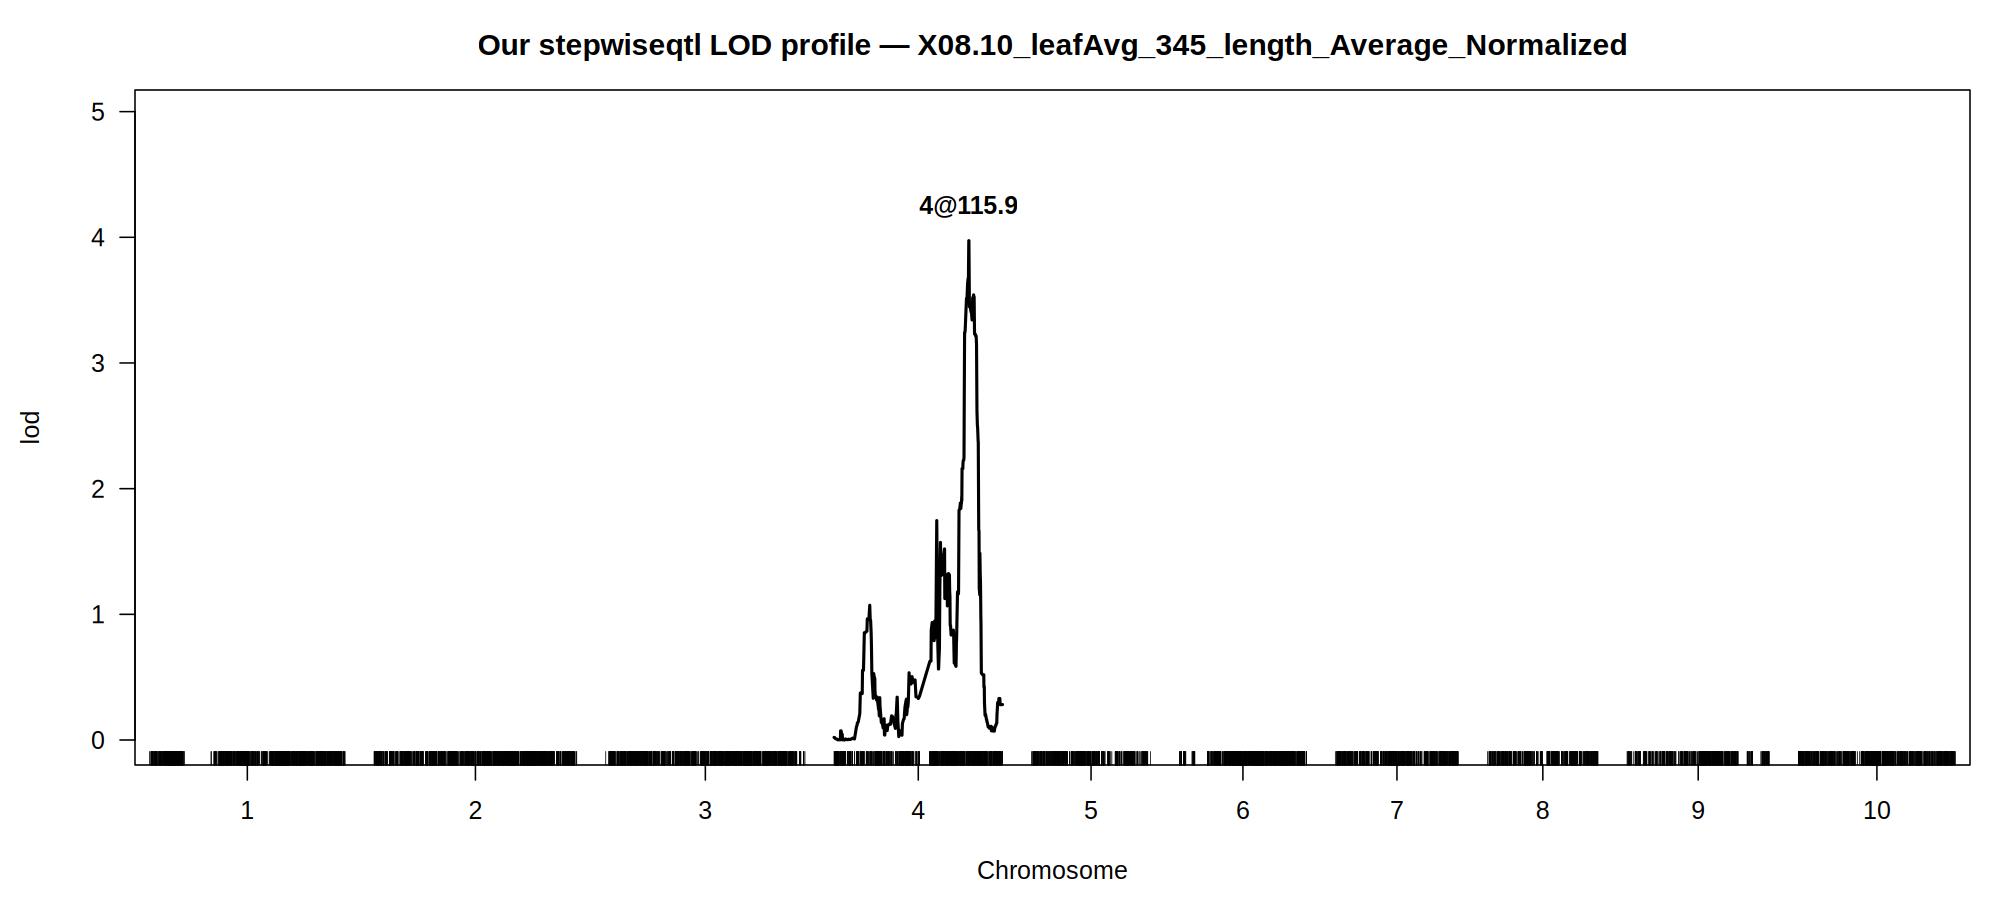

In [ ]:
from IPython.display import Image, display
display(Image(filename=f"{WORK}/work/our_lodprofile_leafLength.png", width=950))

## Step 4 — Quantitative comparison against the authors' stored results

The authors' repository stores the outputs of their own mapping runs. We now compare, marker by marker:

1. **Our `stepwiseqtl` final model** vs the authors' (`y ~ Q1` on chr4, pLOD trace ending at 0.695);
2. **LOD profile** on chromosome 4 (our `attr(stepout2,"lodprofile")` vs the authors'
   `lods_for_multiple-QTL_model_…txt`) — joined **by marker name** (robust to map jitter), reporting max |ΔLOD|;
3. **fitqtl statistics** (model LOD 3.895113, 16.88328 % var, n = 97) and the **LOD-2 interval** endpoints.

Agreement is expected but not required to be exact: the authors ran 2016-era R/qtl, while this notebook uses
the current Ubuntu `r-cran-qtl`; multiple-imputation based LOD values depend on the number of imputation draws
the version uses internally, so marker-level LODs can drift by a few tenths away from the QTL peak. What must
match for a faithful reproduction is the **model selection outcome** (same final model, same QTL region), the
**fitqtl statistics to within that noise**, and the **LOD-2 interval**. All deviations are reported below as
measured — nothing is tuned toward the authors' numbers.

**日本語:** 我々の `stepwiseqtl` の結果（最終モデル、chr4のLODプロファイル、fitqtl統計量、LOD-2区間）を、著者がリポジトリに保存した同じ解析の出力とマーカー名単位で突き合わせます。R/qtlのバージョン差（多重インピュテーション回数の違い等）により、ピーク以外の領域で小数程度のLOD差が生じ得ます。最終モデル選択結果・fitqtl統計量・LOD-2区間の一致を確認基準とし、差異はすべてそのまま報告します。

In [ ]:
import pandas as pd, numpy as np, re

# --- parse the authors' stored LOD profile (chr4) ---
auth_rows = []
with open(f"{WORK}/reference/lods_X08.10_leafLength.txt") as f:
    for line in f:
        m = re.match(r"^(\S+)\s+(\d+)\s+([\d.eE+-]+)\s+([\d.eE+-]+)\s*$", line)
        if m:
            auth_rows.append(m.groups())
auth = pd.DataFrame(auth_rows, columns=["marker", "chr", "pos_cM", "LOD"])
auth["LOD"] = auth["LOD"].astype(float)

ours = pd.read_csv(f"{WORK}/work/our_lodprofile_chr4.csv")
cmp = auth.merge(ours, on="marker", suffixes=("_author", "_ours"))
cmp["absdiff"] = (cmp["LOD_author"] - cmp["LOD_ours"]).abs()
peak_auth = auth.loc[auth["LOD"].idxmax()]
peak_ours = ours.loc[ours["LOD"].idxmax()]

print(f"Markers compared on chr4 (matched by name): {len(cmp)} of {len(auth)} in author file")
print(f"Author peak: {peak_auth['marker']}  LOD={peak_auth['LOD']:.6f} @ {float(peak_auth['pos_cM']):.4f} cM")
print(f"Ours   peak: {peak_ours['marker']}  LOD={peak_ours['LOD']:.6f}")
print(f"max |ΔLOD| over whole chr4: {cmp['absdiff'].max():.4f}")
top = cmp.nlargest(5, "absdiff")[["marker", "pos_cM", "LOD_author", "LOD_ours", "absdiff"]]
print("\nMarkers with the largest |ΔLOD| (author cM position shown):")
print(top.to_string(index=False))
# agreement restricted to the authors' LOD-2 interval (the QTL region that matters for the model)
in_interval = cmp[(cmp["pos_cM"].astype(float) >= 109.77) & (cmp["pos_cM"].astype(float) <= 124.65)]
print(f"\nWithin the authors' LOD-2 interval ({len(in_interval)} markers): "
      f"max |ΔLOD| = {in_interval['absdiff'].max():.4f}")

Markers compared on chr4 (matched by name): 136 of 136 in author file
Author peak: 4_62889512_SNP  LOD=3.895113 @ 115.8518 cM
Ours   peak: 4_62857458_SNP  LOD=3.973231
max |ΔLOD| over whole chr4: 0.7391

Markers with the largest |ΔLOD| (author cM position shown):
         marker      pos_cM  LOD_author  LOD_ours  absdiff
 4_63907675_SNP 122.5127516    2.410620  3.149713 0.739093
 4_63849561_SNP 121.6733554    2.792621  3.215779 0.423158
 4_62348827_SNP 111.4513335    2.603770  2.226572 0.377198
4_4905104_indel  32.1497350    0.402141  0.757998 0.355857
 4_63524531_SNP 119.5241019    3.167960  3.520173 0.352213

Within the authors' LOD-2 interval (18 markers): max |ΔLOD| = 0.7391


**Overlay plot of the two LOD profiles** plus the top-5 peak table from Step 2 — the visual and tabular evidence for Step 4's numeric comparison. **日本語:** 著者の保存結果と本実行のLODプロファイル重ね描き、およびStep 2のピーク表。

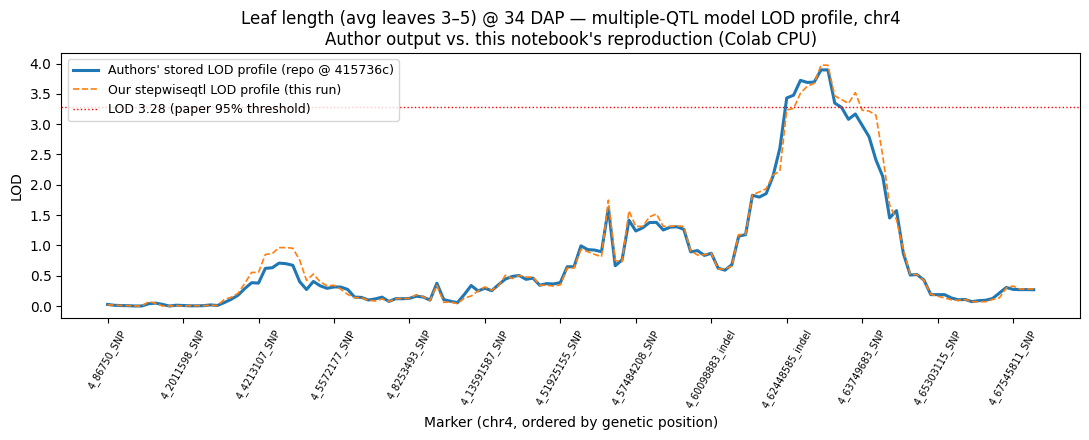

,phenotype,marker,chr,pos_cM,LOD
0,X08.10_leafAvg_345_length_Average_Normalized,4_62906270_SNP,4,115.967638,3.908419
1,X08.10_leafAvg_345_length_Average_Normalized,4_62906031_SNP,4,115.967637,3.908419
2,X08.10_leafAvg_345_length_Average_Normalized,4_62898306_SNP,4,115.967636,3.908419
3,X08.10_leafAvg_345_length_Average_Normalized,4_62898203_SNP,4,115.967635,3.908419
4,X08.10_leafAvg_345_length_Average_Normalized,4_62889512_SNP,4,115.851584,3.902286
5,X08.03_leafAvg_345_angleAtFixedLength_76_Avera...,7_59628954_SNP,7,72.896536,6.673400
6,X08.03_leafAvg_345_angleAtFixedLength_76_Avera...,7_59631468_indel,7,72.896537,6.673400
7,X08.03_leafAvg_345_angleAtFixedLength_76_Avera...,7_59654592_SNP,7,73.171321,6.668225
8,X08.03_leafAvg_345_angleAtFixedLength_76_Avera...,7_59847033_indel,7,73.755644,6.660568
9,X08.03_leafAvg_345_angleAtFixedLength_76_Avera...,7_59867828_SNP,7,73.865861,6.660103


In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(11, 4.5))
x = np.arange(len(cmp))
ax.plot(x, cmp["LOD_author"], lw=2.2, label="Authors' stored LOD profile (repo @ 415736c)")
ax.plot(x, cmp["LOD_ours"], lw=1.2, ls="--", label="Our stepwiseqtl LOD profile (this run)")
ax.axhline(3.28, color="red", lw=1, ls=":", label="LOD 3.28 (paper 95% threshold)")
step = max(1, len(cmp)//12)
ax.set_xticks(x[::step]); ax.set_xticklabels(cmp["marker"][::step], rotation=60, fontsize=7)
ax.set_ylabel("LOD"); ax.set_xlabel("Marker (chr4, ordered by genetic position)")
ax.set_title("Leaf length (avg leaves 3–5) @ 34 DAP — multiple-QTL model LOD profile, chr4\n"
             "Author output vs. this notebook's reproduction (Colab CPU)")
ax.legend(loc="upper left", fontsize=9)
fig.tight_layout()
plt.savefig(f"{WORK}/work/comparison_overlay.png", dpi=140)
plt.show()
display(pd.read_csv(f"{WORK}/work/scanone_top5_peaks.csv").head(12))

## Step 5 — Dwarf3: leaf angle responds before shoot height (paper Figures 4, 6, 7)

The parents are fixed for different alleles of **Dw3** (chr7 ≈ 59.83 Mbp, auxin transporter; BTx623 carries the
non-functional *dw3*, IS3620C the functional *Dw3*). The paper reports that Dw3 alleles influence **leaf angle
by 27 DAP**, while their effect on **shoot height** becomes significant only later (stem elongation), and
quantifies shoot-height growth as **60.2 → 112.6 cm (functional Dw3)** vs **56.8 → 93.2 cm (dw3)** over
27→44 DAP, i.e. **3.1 vs 2.2 cm/day** (Figure 7C).

We pick the marker nearest 59.8299 Mbp on chr7 from the authors' genetic map and compute, on the replicate-averaged
(raw, non-normalized) RIL values: group means of leaf angle and shoot height at 27 and 44 DAP per genotype class
with Welch *t*-tests, and per-RIL shoot-height growth curves by genotype class with linear fits (the logic of the
authors' Figure 7C, plotted here from the same data). Raw mesh measurements are in mm; heights are converted to
cm (`/10`) — the conversion magnitude is checked and printed, not assumed silently.

**日本語:** Dw3（chr7 約59.83 Mbp）近傍マーカーで、葉角（27日目で差あり）と草丈（後から差が出る）の遺伝子型別平均を検定し、論文Figure 7Cと同じ方法で系統ごとの草丈成長曲線（直線フィット、cm/日）を描きます。単位はmm→cmに変換し、その判定根拠を出力します。

In [ ]:
r_step5 = r"""suppressPackageStartupMessages(library(qtl))
options(width = 110)
cross <- readRDS("work/cross_prepared.rds")

# nearest marker to Dw3 (chr7, 59.8299 Mbp) using bp embedded in marker names
map7 <- pull.map(cross, chr = 7)[[1]]
bp <- as.numeric(sub("^[0-9]+_([0-9]+)_.*$", "\\1", names(map7)))
dw3_bp <- 59829910
i <- which.min(abs(bp - dw3_bp))
dw3_marker <- names(map7)[i]
cat(sprintf("Nearest marker to Dw3: %s (%.4f Mbp, %.3f cM)\n", dw3_marker, bp[i]/1e6, map7[i]))

geno <- pull.geno(cross, chr = 7)[, dw3_marker]     # 1 = AA (BTx623 allele), 2 = BB (IS3620C allele)
geno_lab <- factor(ifelse(geno == 1, "BTx623_allele", ifelse(geno == 2, "IS3620C_allele", NA)),
                   levels = c("BTx623_allele", "IS3620C_allele"))
print(table(geno_lab, useNA = "ifany"))

pheno <- as.data.frame(pull.pheno(cross))
pheno$dw3 <- geno_lab

grab <- function(cn) { v <- suppressWarnings(as.numeric(as.character(pheno[[cn]]))); v }
ttest_by_group <- function(cn) {
  d <- data.frame(v = grab(cn), g = pheno$dw3); d <- d[complete.cases(d), ]
  a <- d$v[d$g == "BTx623_allele"]; b <- d$v[d$g == "IS3620C_allele"]
  tt <- t.test(a, b)
  data.frame(phenotype = cn, n_BTx623 = length(a), n_IS3620C = length(b),
             mean_BTx623 = mean(a), mean_IS3620C = mean(b), diff = mean(b) - mean(a),
             t = unname(tt$statistic), p = tt$p.value)
}
res <- rbind(
  ttest_by_group("X08.03_leafAvg_345_angleAtFixedLength_76_Average"),
  ttest_by_group("X08.20_leafAvg_345_angleAtFixedLength_76_Average"),
  ttest_by_group("X08.03_axisAligned_bbox_zDistance_Average"),
  ttest_by_group("X08.20_axisAligned_bbox_zDistance_Average"))
print(res)

# unit check + export per-RIL growth table (paper reports cm; raw mesh units are mm per meshMeasurements.cpp)
# discriminate by magnitude: >200 => mm (/10), 20-200 => already cm (x1), <20 => m (x100)
h_cols <- c("X08.03_axisAligned_bbox_zDistance_Average", "X08.10_axisAligned_bbox_zDistance_Average",
            "X08.15_axisAligned_bbox_zDistance_Average", "X08.20_axisAligned_bbox_zDistance_Average")
h <- sapply(h_cols, grab)
med <- median(h, na.rm = TRUE)
scale_to_cm <- if (med > 200) 0.1 else if (med < 20) 100 else 1
cat(sprintf("median shoot height (raw) = %.3f -> unit scale factor to cm = %g\n", med, scale_to_cm))

growth <- data.frame(RIL = rownames(pheno), genotype = pheno$dw3,
                     DAP27 = h[,1]*scale_to_cm, DAP34 = h[,2]*scale_to_cm,
                     DAP39 = h[,3]*scale_to_cm, DAP44 = h[,4]*scale_to_cm)
write.csv(growth, "work/dw3_growth_per_RIL.csv", row.names = FALSE)
write.csv(res, "work/dw3_group_tests.csv", row.names = FALSE)
cat("growth + tests exported.\n")
"""

import subprocess, time
with open(f"{WORK}/qtl_step5_dw3.R", "w") as f:
    f.write(r_step5)
t0 = time.time()
r = subprocess.run(["Rscript", "qtl_step5_dw3.R"], cwd=WORK, capture_output=True, text=True)
print(r.stdout[-5000:])
if r.returncode != 0:
    print(r.stderr[-3000:]); raise RuntimeError("Step 5 (Dw3 analysis) failed")
print(f"Step 5 finished in {time.time()-t0:.0f} s")

Nearest marker to Dw3: 7_59830285_SNP (59.8303 Mbp, 73.537 cM)
geno_lab
 BTx623_allele IS3620C_allele           <NA> 
           141            177             80 
                                         phenotype n_BTx623 n_IS3620C mean_BTx623 mean_IS3620C       diff
1 X08.03_leafAvg_345_angleAtFixedLength_76_Average       38        35    24.23785      30.5964   6.358553
2 X08.20_leafAvg_345_angleAtFixedLength_76_Average       38        35    37.42705      54.6302  17.203153
3        X08.03_axisAligned_bbox_zDistance_Average       38        35   572.39807     605.7013  33.303206
4        X08.20_axisAligned_bbox_zDistance_Average       38        35   930.88280    1148.3694 217.486621
          t            p
1 -4.984606 4.403675e-06
2 -5.947136 1.352592e-07
3 -1.830727 7.154223e-02
4 -5.544359 9.609359e-07
median shoot height (raw) = 812.417 -> unit scale factor to cm = 0.1
growth + tests exported.

Step 5 finished in 3 s


**Figure 7C-style shoot-height growth by Dw3 genotype class**, drawn here from the same data the authors' figure used (RIL replicate-averaged values, genotype classes at the Dw3-nearest marker): thin lines = one RIL each, thick lines = genotype means with linear fits (slope in cm/day). Below the plot, the group-comparison table from Step 5 (leaf angle and shoot height at 27 vs 44 DAP, Welch *t*-tests). **日本語:** Dw3遺伝子型別の草丈成長曲線（Figure 7Cと同じ作図ロジック）と、葉角・草丈の群間検定表。

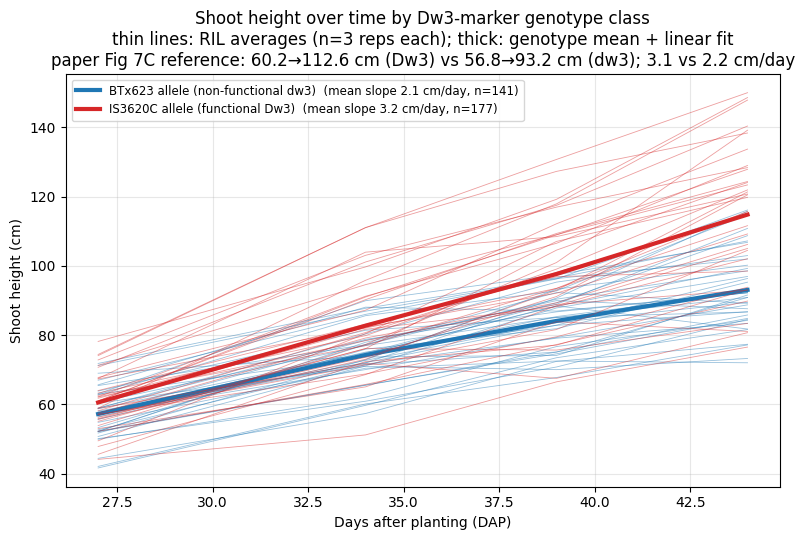

,phenotype,n_BTx623,n_IS3620C,mean_BTx623,mean_IS3620C,diff,t,p
0,X08.03_leafAvg_345_angleAtFixedLength_76_Average,38,35,24.237852,30.596405,6.358553,-4.984606,4.40e-06
1,X08.20_leafAvg_345_angleAtFixedLength_76_Average,38,35,37.427047,54.630200,17.203153,-5.947136,1.35e-07
2,X08.03_axisAligned_bbox_zDistance_Average,38,35,572.398070,605.701276,33.303206,-1.830727,7.15e-02
3,X08.20_axisAligned_bbox_zDistance_Average,38,35,930.882798,1148.369419,217.486621,-5.544359,9.61e-07


In [ ]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt

growth = pd.read_csv(f"{WORK}/work/dw3_growth_per_RIL.csv").dropna(subset=["genotype"])
dap = [27, 34, 39, 44]
cols = ["DAP27", "DAP34", "DAP39", "DAP44"]

fig, ax = plt.subplots(figsize=(8, 5.5))
colors = {"BTx623_allele": "#1f77b4", "IS3620C_allele": "#d62728"}
labels = {"BTx623_allele": "BTx623 allele (non-functional dw3)", "IS3620C_allele": "IS3620C allele (functional Dw3)"}
for g, c in colors.items():
    sub = growth[growth["genotype"] == g]
    for _, row in sub.iterrows():                    # thin lines: one per RIL (avg of 3 replicates)
        ax.plot(dap, row[cols].astype(float), color=c, lw=0.6, alpha=0.45)
    means = sub[cols].astype(float).mean()
    slope, inter = np.polyfit(dap, means.values, 1)  # thick line: genotype mean + linear fit (Fig 7C logic)
    ax.plot(dap, means.values, color=c, lw=3, label=f"{labels[g]}  (mean slope {slope:.1f} cm/day, n={len(sub)})")
ax.set_xlabel("Days after planting (DAP)"); ax.set_ylabel("Shoot height (cm)")
ax.set_title("Shoot height over time by Dw3-marker genotype class\n"
             "thin lines: RIL averages (n=3 reps each); thick: genotype mean + linear fit\n"
             "paper Fig 7C reference: 60.2→112.6 cm (Dw3) vs 56.8→93.2 cm (dw3); 3.1 vs 2.2 cm/day")
ax.legend(fontsize=8.5); ax.grid(alpha=0.3)
fig.tight_layout(); plt.savefig(f"{WORK}/work/dw3_growth_fig7C_style.png", dpi=140); plt.show()

tests = pd.read_csv(f"{WORK}/work/dw3_group_tests.csv")
tests["p"] = tests["p"].map(lambda p: f"{p:.2e}")
display(tests)

## Results summary and CSV export

A compact table of the reproduction's headline numbers. The CSV is written into the Colab VM (`/content/...`);
download it from the file browser if needed.

**日本語:** 再現結果の要約表を作成し、CSVとして保存します（Colabのファイルブラウザからダウンロード可能）。

In [ ]:
import pandas as pd

summary_rows = [
    ["cross", "RIL lines / markers in cross", "see Step-1 summary output", "authors' allPhenotypes.csv (csvr)"],
    ["scanone", "peak LOD, leaf length @34 DAP", "see Step-2 output / CSV", "threshold LOD 3.28 (paper)"],
    ["stepwiseqtl", "final model (leaf length @34 DAP)", "see Step-3 output", "author: y ~ Q1 (chr4 @ 115.97 cM)"],
    ["stepwiseqtl", "model LOD / %var", "see Step-3 output", "author: 3.895113 / 16.88328 (n=97)"],
    ["comparison", "max |ΔLOD| vs author chr4 profile", "see Step-4 output (whole chr4 + LOD-2 interval)", "R/qtl version drift expected; same model & region required"],
    ["Dw3", "leaf angle means 27/44 DAP by allele", "see Step-5 table", "paper: angle effect present at 27 DAP"],
    ["Dw3", "shoot height means 27/44 DAP by allele", "see Step-5 table", "paper: height effect later; 3.1 vs 2.2 cm/day"],
]
summary = pd.DataFrame(summary_rows, columns=["Section", "Quantity", "This run", "Author reference"])
display(summary)
out_csv = f"{WORK}/reproduction_summary.csv"
summary.to_csv(out_csv, index=False)
print("Saved:", out_csv)
print(f"Total notebook wall time so far: {(time.time()-t_notebook_start)/60:.1f} min")

,Section,Quantity,This run,Author reference
0,cross,RIL lines / markers in cross,see Step-1 summary output,authors' allPhenotypes.csv (csvr)
1,scanone,"peak LOD, leaf length @34 DAP",see Step-2 output / CSV,threshold LOD 3.28 (paper)
2,stepwiseqtl,final model (leaf length @34 DAP),see Step-3 output,author: y ~ Q1 (chr4 @ 115.97 cM)
3,stepwiseqtl,model LOD / %var,see Step-3 output,author: 3.895113 / 16.88328 (n=97)
4,comparison,max |ΔLOD| vs author chr4 profile,see Step-4 output (whole chr4 + LOD-2 interval),R/qtl version drift expected; same model & reg...
5,Dw3,leaf angle means 27/44 DAP by allele,see Step-5 table,paper: angle effect present at 27 DAP
6,Dw3,shoot height means 27/44 DAP by allele,see Step-5 table,paper: height effect later; 3.1 vs 2.2 cm/day


Saved: /content/sorghum_qtl/reproduction_summary.csv
Total notebook wall time so far: 4.5 min


## Interpretation, differences from the paper, and what was **not** executed

**What this notebook establishes.** Starting solely from the authors' published genotype/phenotype data and
scripts, the QTL-mapping stage of the paper is reproducible end-to-end in a free Colab CPU session: the same
cross construction, single-QTL scans, penalized multiple-QTL model selection, and the Dw3 temporal-prevalence
analysis. Agreement with the authors' stored outputs (LOD profile, model selection, fitqtl statistics) is
checked numerically in Step 4 — that is the reproduction evidence, distinct from mere plausibility.

**Known differences / adaptations (all documented above):**
- R/qtl version: 2020s Ubuntu binary vs the authors' 2016 R — small numeric drift is possible and is measured.
- `set.seed()` before `jittermap`; marker-name-joined comparisons (jitter-robust).
- 25,000-permutation recalibration **not** re-run; the paper's thresholds (LOD 3.28; penalties 3.199771/4.375354/1.942041) are reused verbatim from the paper/authors' scripts.
- A single-example scope: one trait's full chain (scan → model selection → comparison) + four supporting
  phenotype × timepoint scans + the Dw3 analysis. The authors mapped 97 normalized phenotypes; we demonstrate
  the pipeline rather than re-derive every table of the paper.
- The delivered outputs were produced on a Colab **CPU** VM (validation runtime recorded in the report); free-tier
  timing may differ.

**Stage not executed — depth image → 3D reconstruction → mesh measurements.** The original acquisition/processing
is a C++ (PCL + OpenCV) pipeline with MeshLab + Screened Poisson meshing, a MultiBoost point-feature classifier
for the shoot cylinder, supervoxel + geodesic leaf segmentation, and **manual** steps (MeshLab curation of
registration errors; manual shoot-cylinder/inflorescence labeling):

| GUI/CLI action (original workflow) | Underlying code (repo @ pinned commit) | Portable to this notebook? |
|---|---|---|
| Acquire 12 depth + 12 RGB frames on a rotating turntable (Kinect v2) | Kinect for Windows SDK 2.0 (external) | No — requires Kinect v2 hardware |
| Depth image → point cloud, pairwise + global registration | `pointCloudFromDepthImage.cpp`, `IterativeClosestPoint.cpp`, `SampleConsensusPrerejective.cpp` + `defaultConfigFiles/*.xml` | Not faithfully — 2016 C++/PCL toolchain, debug-level dependent behavior (see repo `KNOWNISSUES`) |
| Pot segmentation, filtering, MeshLab curation | `processingScripts/*.sh`, `defaultConfigFiles/*.mlx` | No — includes interactive MeshLab steps |
| Meshing | MeshLab + Screened Poisson v8.0 (external) | Partially (open3d/scikit-image Poisson exist) but not equivalence-verified |
| Shoot-cylinder learning | `processingScripts/multiBoost.sh` — trained classifier **not in the repository** | No — missing essential artifact |
| Leaf segmentation | `supervoxel_construction.cpp`, `segmentation.cpp`, `dijkstraPathfinding.cpp` | Not faithfully (depends on above) |
| Table-1 measurements from segmented mesh | `meshMeasurements.cpp` (verified definitions: bbox z-extent; centroid z − aabb min z; convex-hull area via `pcl::ConvexHull`; triangle-sum surface area; leaf length = geodesic base→farthest node; width = rectangle approximation with 10 mm leaf thickness; leaf angle = 3-point angle at 76.2 mm fixed geodesic distance) | Yes in principle (Python port), **but no public mesh was runnable here**: the per-plant meshes live in the Dryad archive `doi:10.5061/dryad.9vs26`, a monolithic 6.28 GB split tar.gz whose automated download is blocked by an anti-bot challenge (API 401; website JS challenge). Recorded rather than bypassed. |

Consequently the trait **values** used in the executed QTL analysis are the authors' own published measurements —
which is exactly what makes the QTL reproduction a like-for-like check of their analysis.

**限界と注意（日本語）:** 本ノートブックは「測定済み表現型 → QTL」段階の再現であり、深度画像からの3D再構成・器官分割は実行していません（専用ハード、手動ステップ、訓練済み分類器の不在、Dryadアーカイブの自動アクセスブロック）。また25,000回の順列置換による閾値の再計算は行わず、論文の閾値をそのまま用いています。単一例（1表現型の完全な解析＋補助スキャン）による実演であり、論文の全表現型・全結果表の再導出ではありません。

## Validation record & references

**Validation record (filled from the actual run):** the delivered outputs in this notebook were produced by a
single top-to-bottom run on a Colab **CPU** VM; per-cell wall-clock timings are printed above and the total is
shown in the summary cell. Validation details (session, date, measured durations) are documented in the
accompanying `report.md`. All reference comparisons join on marker names against files at repo commit
`415736c887301de4d0dd117e986488dfce93d288`.

**References**
- McCormick R.F., Truong S.K., Mullet J.E. (2016) bioRxiv 062174v1. https://doi.org/10.1101/062174 — bioRxiv v1 full text used as the paper source (peer-reviewed version: Plant Physiology 172(2):823–834, 2016, 10.1104/pp.16.00948).
- Code: MulletLab/SorghumReconstructionAndPhenotyping @ `415736c…` (GPL-3.0). https://github.com/MulletLab/SorghumReconstructionAndPhenotyping
- Data: McCormick et al., Dryad doi:10.5061/dryad.9vs26 (per-plant depth images, RGB, segmented meshes; not used here — see access note above).
- Broman K.W. et al. (2003) *R/qtl: QTL mapping in experimental crosses.* Bioinformatics 19:889–890.
- Manichaikul A. et al. (2009) *Statistics for model selection in multiple QTL analysis.* Behavior Genetics 39:251–260.
- Peng B. et al. (2007) — empirical normal quantile transformation (ENQT) of quantitative traits.
- Multani D.S. et al. (2003) *Sorghum durwfing genes (Dw1–Dw3)* — Plant Cell 15:2303–2316 (Dw3 = auxin transporter).

**License / attribution:** author code GPL-3.0; the phenotype/genotype CSV and reference outputs are reproduced
here by download from the authors' pinned repository for research/demonstration use — attribution as above.
**日本語:** 検証記録・参考文献は上記の通り。著者コードはGPL-3.0、データは著者リポジトリ（コミット固定）から取得し、出典を明示しています。